# OpenQARP (Fujitsu) — Quick-Start Testing Notebook

This notebook is a hands-on test drive of **OpenQARP** (Open Quantum Application Research Package), the modular quantum-application framework Fujitsu open-sourced under Apache 2.0 in September 2026.

OpenQARP's mental model is three composable pieces:

1. **Block** — the circuit itself (qubits + gates).
2. **Primitive** — what you want out of the circuit (a sample distribution, an expectation value, an energy, etc.).
3. **Engine** — what runs it (a local simulator here; the same code can target GPU-accelerated or large-scale backends).

Everything else in the package — VQE, QAOA, QPE, circuit cutting, noisy simulation — is just those three pieces with more interesting parts plugged in. That's the "modular by design" idea: instead of writing 100+ lines of gate-level code per algorithm, you assemble pre-built, tested components.

**What we'll test:**
- Example 1: Build and sample a Bell state (the "hello world" of quantum circuits)
- Example 2: Measure an observable exactly vs. with finite shots
- Example 3: A small VQE-style ground-state energy search (the composable-blocks idea applied to a real algorithm)

> **Note:** This notebook targets `openqarp` v0.1.0. If a method name below doesn't match your installed version exactly, check the [official examples](https://github.com/OpenQARP/openqarp/tree/main/examples) and [tutorial](https://openqarp.github.io/openqarp/source/tutorial.html) — the package is brand new and the API may evolve.  

By Carlos Araque  
@KentryOps Data Labs  
Quantum researchers  
18-09-2026

## 0. Install

Wheels ship for Linux, macOS and Windows on Python 3.11–3.14 — Colab's default runtime is covered, so this should be a fast binary install (no compiling).

In [1]:
!pip install -q openqarp

import qarp
print("OpenQARP (qarp) imported OK.")
print("Version:", getattr(qarp, "__version__", "unknown"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 102.0 MB/s eta 0:00:00
OpenQARP (qarp) imported OK.
Version: 0.1.0


---
## Example 1 — Build a circuit and sample it (Bell state)

A **block** is a circuit. You state the qubit count, add gates, add measurements, then `build()` it. A **Sampler** primitive asks for the distribution of measured bitstrings; a **QarpEngine** runs it.

Bell state `|00⟩ + |11⟩` (up to normalization) should give roughly 50/50 outcomes on `00` and `11`, and (ideally) nothing on `01`/`10`.

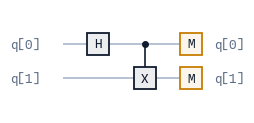

In [2]:
from qarp.blocks import SimpleBlock
from qarp.algorithms import Sampler
from qarp.engines import QarpEngine

# 1. Block: a 2-qubit Bell-state circuit
bell = SimpleBlock(2, name="bell")
bell.h(0)
bell.cx(0, 1)
bell.measure([(q, q) for q in range(2)])  # measure qubit q into classical bit q
bell.build()

bell.plot()  # draws the circuit diagram inline

In [3]:
# 2. Primitive + Engine: sample the circuit 4000 times
sampler = Sampler(ket=bell, n_shots=4000)

engine = QarpEngine(seed=42)   # seed makes shots reproducible
engine.build([sampler])
results = engine.run()

print("Bell state measurement distribution:")
for bitstring, prob in results[0].items():
    print(f"  {bitstring}: {prob:.4f}")

assert abs(results[0].get((0, 0), 0) - 0.5) < 0.05, "Expected ~50% on (0,0)"
assert abs(results[0].get((1, 1), 0) - 0.5) < 0.05, "Expected ~50% on (1,1)"
print("\n✅ Sanity check passed: entanglement produced the expected 50/50 split.")

Bell state measurement distribution:
  (0, 0): 0.4888
  (1, 1): 0.5112

✅ Sanity check passed: entanglement produced the expected 50/50 split.


---
## Example 2 — Expectation values: exact vs. shot-based

Swap the primitive to get an expectation value instead of a raw distribution — computed **exactly** from the statevector, or **sampled** with finite shots, off the *same* circuit definition. This is a nice illustration of "modular by design": one block, two different ways of extracting information from it.

We'll build the operator `H = Z0 Z1 + 0.5 * X0 X1` and check both methods agree (up to shot noise) with the hand-computed value ⟨H⟩ = 1.5 for the Bell state.

In [4]:
from qarp.operators import QubitOperator
from qarp.algorithms import PauliAveraging, StateVector

# Same Bell circuit, but no measurements this time — expectation-value
# primitives read the statevector/shots directly.
circuit = SimpleBlock(2, name="bell_no_meas")
circuit.h(0)
circuit.cx(0, 1)
circuit.build()

H = QubitOperator("Z0 Z1") + 0.5 * QubitOperator("X0 X1")

exact = StateVector(ket=circuit, operator=H)
shots = PauliAveraging(ket=circuit, operator=H, n_shots=4000)

engine = QarpEngine(seed=42)
engine.build([exact, shots])
results = engine.run()

print(f"Exact ⟨H⟩ (statevector):   {results[0].real:.4f}")
print(f"Sampled ⟨H⟩ (4000 shots):  {results[1]:.4f}")
print(f"Hand-computed expectation: 1.5000")

assert abs(results[0].real - 1.5) < 1e-6, "Exact value should match analytically"
assert abs(results[1] - 1.5) < 0.1, "Sampled value should be close, within shot noise"
print("\n✅ Sanity check passed: exact and sampled expectation values agree.")

Exact ⟨H⟩ (statevector):   1.5000
Sampled ⟨H⟩ (4000 shots):  1.5000
Hand-computed expectation: 1.5000

✅ Sanity check passed: exact and sampled expectation values agree.


---
## Example 3 — A small VQE-style ground-state search

This is the kind of workflow OpenQARP is built to shrink: Fujitsu reports an ADAPT-VQE chemistry routine that went from ~130 lines of hand-rolled Python down to under 40 lines using the package's reusable ansatz and estimator components.

Here we do a minimal version of the same idea by hand — build a **parameterized ansatz block**, wrap it with the `StateVector` expectation-value primitive, and drive the parameters with a classical optimizer (SciPy) to find the ground-state energy of a 2-qubit Hamiltonian:

`H = Z0 Z1 + 0.5 * X0 + 0.5 * X1`

which has a known minimum eigenvalue we can check against with plain NumPy.

> If your installed version exposes a ready-made `VQE` algorithm class (per the package's "20+ ready-to-run algorithms"), you can swap this manual loop for that — check `qarp.algorithms.VQE` / the tutorial notebooks for the exact call signature, since packaged, higher-level entry points are exactly what OpenQARP is designed to save you from writing yourself.

In [5]:
import numpy as np

# --- Ground truth via plain linear algebra, for comparison ---
I = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Z = np.array([[1, 0], [0, -1]])

H_matrix = (
    np.kron(Z, Z)
    + 0.5 * np.kron(X, I)
    + 0.5 * np.kron(I, X)
)
true_ground_energy = np.linalg.eigvalsh(H_matrix).min()
print(f"True ground-state energy (NumPy eigensolver): {true_ground_energy:.6f}")

True ground-state energy (NumPy eigensolver): -1.414214


In [8]:
from scipy.optimize import minimize

H_vqe = QubitOperator("Z0 Z1") + 0.5 * QubitOperator("X0") + 0.5 * QubitOperator("X1")

def energy(params):
    """Build a hardware-efficient-style ansatz with the given parameters,
    then evaluate <H> exactly for it via the StateVector primitive."""
    theta0, theta1, theta2 = params

    ansatz = SimpleBlock(2, name="ansatz")
    ansatz.ry(0, theta0)
    ansatz.ry(1, theta1)
    ansatz.cx(0, 1)
    ansatz.ry(0, theta2)
    ansatz.build()

    estimator = StateVector(ket=ansatz, operator=H_vqe)
    engine = QarpEngine(seed=0)
    engine.build([estimator])
    return engine.run()[0].real

# Classical optimization loop driving the quantum circuit evaluations
x0 = np.random.default_rng(42).uniform(0, 2 * np.pi, size=3)
opt_result = minimize(energy, x0, method="COBYLA", options={"maxiter": 200})

print(f"VQE-found ground-state energy:  {opt_result.fun:.6f}")
print(f"True ground-state energy:       {true_ground_energy:.6f}")
print(f"Absolute error:                 {abs(opt_result.fun - true_ground_energy):.6f}")

if abs(opt_result.fun - true_ground_energy) < 0.05:
    print("\n✅ VQE loop converged close to the true ground-state energy.")
else:
    print("\n⚠️ Didn't fully converge — try more iterations, a different optimizer, or a deeper ansatz.")

VQE-found ground-state energy:  -1.414214
True ground-state energy:       -1.414214
Absolute error:                 0.000000

✅ VQE loop converged close to the true ground-state energy.


---
## Wrap-up

If all three examples ran and passed their checks, your OpenQARP install is working end to end: circuit building, sampling, exact/shot-based expectation values, and a classical-quantum optimization loop.

**Where to go next:**
- Official tutorials (`tutorial_00` … `tutorial_05`, ~1 hour end to end): https://github.com/OpenQARP/openqarp/tree/main/examples
- Full docs: https://openqarp.github.io/openqarp/
- Try swapping the local `QarpEngine` for NVIDIA CUDA-Q as a backend (source build required) to test GPU acceleration.
- Explore the ready-to-run algorithms library (VQE, VQD, SSVQE, ADAPT-VQE/VQD, QAOA, QPE, DOS-QPE, PCE) instead of hand-rolling the optimization loop above.